# Comparison of samples

Apply to summary files (output from summary_celltypes_IHOPE.py) in CSV format.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Normalization method used throughout this notebook. Change it in one
# place; every path and filename below is built from it. Must match the
# NORM value used wherever these files are produced or consumed in the
# other notebooks (batch_celltyping_IHOPE.ipynb,
# rulebased_celltyping_IHOPE.ipynb, rulebased_celltyping_with_banksy.ipynb,
# Follicle_counting.ipynb, IHOPE_spatialplots.ipynb,
# figures_svg_export.ipynb, Sample_comparison_IHOPE.ipynb).
NORM = "zscore"   # "zscore", "arcsinh", or "none", matching scripts/transforms.py


In [ ]:
import importlib
from scripts import comparison

importlib.reload(comparison)
from scripts.comparison import (
    load_celltype_summaries,
    pivot_for_heatmap,
    plot_celltype_heatmap,
    print_numeric_summary,
    pivot_for_tissue_heatmap,
    plot_celltype_clustermap,
    plot_celltype_stacked_barplot,
    plot_celltype_stripplot,
    normalise_to_parent,
    parent_ratio_labels,
    plot_tissue_correlation_scatter
)

Define file names and sample names. Use the output from cell 1 to complete cell 2.

In [ ]:
# Make a "fill the gap" template
summaries_dir = PROJECT_ROOT / "results" / "reports" / NORM
files = sorted(summaries_dir.glob("celltype_summary_*.csv"))

print("name_map = {")
for f in files:
    print(f'    "{f.name}": "",')
print("}")


In [ ]:
# Maps each summary file to the sample name used in plots.
# To rename a sample or add a new one, edit NAME_MAP in scripts/celltype_config.py.
from scripts.celltype_config import NAME_MAP as name_map


In [ ]:
file_map = {
    sample: summaries_dir / fname
    for fname, sample in name_map.items()
}

In [ ]:
# Sanity check
for sample, path in file_map.items():
    print(sample, ": ", path.name)

Generate the combined data frame:

In [ ]:
df = load_celltype_summaries(file_map=file_map)

### Donor-grouping:

In [ ]:
# Says which donor each sample belongs to.
# To fix or add one, edit DONOR_MAP in scripts/celltype_config.py.
from scripts.celltype_config import DONOR_MAP as donor_map

df["donor"] = df["sample"].map(donor_map)


Donor color code map

In [ ]:
donor_ids = sorted(set(donor_map.values()))
donor_colors = dict(zip(donor_ids, sns.color_palette("colorblind", n_colors=len(donor_ids))))

### Tissue-grouping:

In [ ]:
# Says which tissue each sample is.
# To fix or add one, edit TISSUE_MAP in scripts/celltype_config.py.
from scripts.celltype_config import TISSUE_MAP as tissue_map

df["tissue"] = df["sample"].map(tissue_map)


Using mean  (avoid dominance of large samples):

In [ ]:
df_tissue = (
    df.groupby(["tissue", "level", "cell_type"], as_index=False)
      .agg(pct_total=("pct_total", "mean"))
)

Decide how you want to handle unannotated cells:

In [ ]:
DROP_UNCLASSIFIED = True   # drop 'unclassified' and rescale to 100, applied in the matrix and barplot calls below
HIDE_UNCLASSIFIED = False  # keep percentages as-is, just drop the unclassified row from heatmaps

Order of cell types for heatmaps:

In [ ]:
# Everything below controls how cell types are grouped, ordered, and
# labeled in the plots in this notebook. This includes which types
# count as structural, which type each subtype belongs to (its
# "parent"), what order rows appear in on heatmaps and barplots, and
# what each type is called in plot text. All of it is defined in
# scripts/celltype_config.py, edits can be made there.
from scripts.celltype_config import (
    STRUCTURAL_CELL_TYPES as structural_cell_types,
    LINEAGE_SUBSETS as lineage_subsets,
    CELLTYPE_ORDER as celltype_order,
    PARENT_OF as parent_of,
    IMMUNE_TYPES as immune_types,
    CELLTYPE_DISPLAY as celltype_display,
)

# lineage_subsets gets a "CD4_T"/"CD8_T" split added below for the
# CD4/CD8 state barplots, so work on a copy rather than mutating the
# shared config module's dict directly.
lineage_subsets = dict(lineage_subsets)


Tissue order

In [ ]:
# The order tissues appear in on plots (left to right, or top to bottom).
# Change TISSUE_ORDER in scripts/celltype_config.py to reorder them.
from scripts.celltype_config import TISSUE_ORDER as tissue_order


In [ ]:
# The color used for each cell type across every plot.
# To change a color, edit CELLTYPE_COLORS in scripts/celltype_config.py.
from scripts.celltype_config import CELLTYPE_COLORS as celltype_colors


### Cell type matrices

Builds the full (all cell types), immune-only, and parent-relative matrices, for sample-level and tissue-level grouping. Pick which one to plot with `HEATMAP_NORM` in the Plots section below.

In [ ]:
matrix_all = pivot_for_heatmap(
    df, celltype_order=celltype_order, tissue_order=tissue_order,
    drop_unclassified=DROP_UNCLASSIFIED, renormalise=DROP_UNCLASSIFIED,
)
matrix_immune = pivot_for_heatmap(
    df, immune_only=True, renormalise=True,
    structural_cell_types=structural_cell_types,
    celltype_order=celltype_order, tissue_order=tissue_order,
)

matrix_tissue_all = pivot_for_tissue_heatmap(
    df_tissue, celltype_order=celltype_order,
    drop_unclassified=DROP_UNCLASSIFIED, renormalise=DROP_UNCLASSIFIED,
)
matrix_tissue_immune = pivot_for_tissue_heatmap(
    df_tissue, immune_only=True, renormalise=True,
    structural_cell_types=structural_cell_types,
    celltype_order=celltype_order,
)


# Parent-relative matrices. Each cell type divided by its parent population.
# Built from the plain all-types matrix, which already holds the parent rows.
matrix_parent = normalise_to_parent(
    pivot_for_heatmap(
        df, celltype_order=celltype_order, tissue_order=tissue_order,
        drop_unassigned=True,
    ),
    parent_of, immune_types,
)
matrix_tissue_parent = normalise_to_parent(
    pivot_for_tissue_heatmap(
        df_tissue, celltype_order=celltype_order, drop_unassigned=True,
    ),
    parent_of, immune_types,
)


## Plots

**Cell type heatmap**

Choose the normalization with `HEATMAP_NORM` ("all", "immune", or "parent") and raw or log percentages with `USE_LOG` in the first block. Parent-relative mode expresses each cell type as a percentage of its parent population, fixes the color scale at 0 to 100, ignores log scaling, and labels each row as "child / parent" (for example "CD4 T cells / T cells").

In [ ]:
USE_LOG = False           # log scaling, ignored when HEATMAP_NORM == "parent"
HEATMAP_NORM = "parent"   # "all", "immune", or "parent", as point of reference for percentages
IMMUNE_ONLY = True        # used by the stacked barplots and stripplots below, not by the heatmaps

# Select the sample-level matrix for the heatmap and the clustermaps below.
if HEATMAP_NORM == "parent":
    matrix = matrix_parent
elif HEATMAP_NORM == "immune":
    matrix = matrix_immune
else:
    matrix = matrix_all

# Parent-relative values are already a percentage of a parent population, so log scaling does not apply and the colour scale is fixed at 0 to 100.
use_log = USE_LOG and HEATMAP_NORM != "parent"
scale_label = "log" if use_log else "linear"

if HEATMAP_NORM == "parent":
    cbar_label = "Percentage"
    heatmap_vmax = 100
else:
    cbar_label = "Log percentage (+0.1)" if use_log else "Percentage"
    heatmap_vmax = None

plot_matrix = np.log10(matrix + 0.1) if use_log else matrix

# Parent-relative mode never contains an unclassified row, so this only acts on the all/immune matrices.
if HIDE_UNCLASSIFIED and HEATMAP_NORM != "parent":
    plot_matrix = plot_matrix.drop(index="unclassified", errors="ignore")
plot_matrix = plot_matrix.fillna(0)

# Changes labels if in parent-relative mode
if HEATMAP_NORM == "parent":
    plot_matrix = parent_ratio_labels(
        plot_matrix, parent_of, immune_types, display_names=celltype_display,
    )


Generate plots:

In [ ]:
import importlib
from scripts import comparison
importlib.reload(comparison)
from scripts.comparison import (
    load_celltype_summaries,
    pivot_for_heatmap,
    plot_celltype_heatmap,
    print_numeric_summary,
    pivot_for_tissue_heatmap,
    plot_celltype_clustermap,
    plot_celltype_stacked_barplot,
    plot_celltype_stripplot,
    normalise_to_parent,
    parent_ratio_labels,
)


In [ ]:
plot_celltype_heatmap(
    plot_matrix,
    scale=scale_label,
    colorbar_legend=cbar_label,
    vmax=heatmap_vmax,
)


**Clustered with correlation metric**

This can be an advantage when sample sizes differ, which they do here

In [ ]:
plot_celltype_clustermap(
    plot_matrix,
    scale=scale_label,
    colorbar_legend=cbar_label,
    cluster_rows=False,
    cluster_cols=True,
    metric="correlation",
    vmax=heatmap_vmax,
)


**Tissue-grouped**

Select raw percentages or log-scaled in the first block.

In [ ]:
USE_LOG = False   # log scaling, ignored when HEATMAP_NORM == "parent"

# Reuses HEATMAP_NORM from the sample-level block above.
if HEATMAP_NORM == "parent":
    matrix_tissue = matrix_tissue_parent
elif HEATMAP_NORM == "immune":
    matrix_tissue = matrix_tissue_immune
else:
    matrix_tissue = matrix_tissue_all

use_log_tissue = USE_LOG and HEATMAP_NORM != "parent"
scale_label = "log" if use_log_tissue else "linear"

if HEATMAP_NORM == "parent":
    cbar_label = "Percentage"
    heatmap_vmax_tissue = 100
else:
    cbar_label = "Percentage (log +0.1)" if use_log_tissue else "Percentage"
    heatmap_vmax_tissue = None

plot_matrix_tissue = np.log10(matrix_tissue + 0.1) if use_log_tissue else matrix_tissue

if HIDE_UNCLASSIFIED and HEATMAP_NORM != "parent":
    plot_matrix_tissue = plot_matrix_tissue.drop(index="unclassified", errors="ignore")

plot_matrix_tissue = plot_matrix_tissue.fillna(0)

if HEATMAP_NORM == "parent":
    plot_matrix_tissue = parent_ratio_labels(
        plot_matrix_tissue, parent_of, immune_types, display_names=celltype_display,
    )


Raw percentages:

In [ ]:
plot_celltype_heatmap(
    plot_matrix_tissue,
    colorbar_legend=cbar_label,
    scale=scale_label,
    vmax=heatmap_vmax_tissue,
    narrow=True,
)


**Lymph nodes only**

In [ ]:
# Lymph-node-only heatmaps (MedLN + MesLN, spleen excluded)
# Reuses HEATMAP_NORM, USE_LOG, HIDE_UNCLASSIFIED, DROP_UNCLASSIFIED,
# celltype_order, structural_cell_types, parent_of and immune_types.

df_ln = df[df["tissue"] != "Spleen"]
df_tissue_ln = df_tissue[df_tissue["tissue"] != "Spleen"]

matrix_all_ln = pivot_for_heatmap(
    df_ln, celltype_order=celltype_order,
    drop_unclassified=DROP_UNCLASSIFIED, renormalise=DROP_UNCLASSIFIED,
)
matrix_immune_ln = pivot_for_heatmap(
    df_ln, immune_only=True, renormalise=True,
    structural_cell_types=structural_cell_types,
    celltype_order=celltype_order,
)
matrix_parent_ln = normalise_to_parent(
    pivot_for_heatmap(
        df_ln, celltype_order=celltype_order, drop_unassigned=True,
    ),
    parent_of, immune_types,
)

matrix_tissue_all_ln = pivot_for_tissue_heatmap(
    df_tissue_ln, celltype_order=celltype_order,
    drop_unclassified=DROP_UNCLASSIFIED, renormalise=DROP_UNCLASSIFIED,
)
matrix_tissue_immune_ln = pivot_for_tissue_heatmap(
    df_tissue_ln, immune_only=True, renormalise=True,
    structural_cell_types=structural_cell_types,
    celltype_order=celltype_order,
)
matrix_tissue_parent_ln = normalise_to_parent(
    pivot_for_tissue_heatmap(
        df_tissue_ln, celltype_order=celltype_order, drop_unassigned=True,
    ),
    parent_of, immune_types,
)

# Select the LN matrices to match HEATMAP_NORM.
if HEATMAP_NORM == "parent":
    matrix_ln = matrix_parent_ln
    matrix_tissue_ln = matrix_tissue_parent_ln
elif HEATMAP_NORM == "immune":
    matrix_ln = matrix_immune_ln
    matrix_tissue_ln = matrix_tissue_immune_ln
else:
    matrix_ln = matrix_all_ln
    matrix_tissue_ln = matrix_tissue_all_ln

use_log_ln = USE_LOG and HEATMAP_NORM != "parent"
scale_label_ln = "log" if use_log_ln else "linear"
if HEATMAP_NORM == "parent":
    cbar_label_ln = "Percentage"
    heatmap_vmax_ln = 100
else:
    cbar_label_ln = "Log percentage (+0.1)" if use_log_ln else "Percentage"
    heatmap_vmax_ln = None

plot_matrix_ln = np.log10(matrix_ln + 0.1) if use_log_ln else matrix_ln
if HIDE_UNCLASSIFIED and HEATMAP_NORM != "parent":
    plot_matrix_ln = plot_matrix_ln.drop(index="unclassified", errors="ignore")
plot_matrix_ln = plot_matrix_ln.fillna(0)
if HEATMAP_NORM == "parent":
    plot_matrix_ln = parent_ratio_labels(
        plot_matrix_ln, parent_of, immune_types, display_names=celltype_display,
    )

plot_matrix_tissue_ln = np.log10(matrix_tissue_ln + 0.1) if use_log_ln else matrix_tissue_ln
if HIDE_UNCLASSIFIED and HEATMAP_NORM != "parent":
    plot_matrix_tissue_ln = plot_matrix_tissue_ln.drop(index="unclassified", errors="ignore")
plot_matrix_tissue_ln = plot_matrix_tissue_ln.fillna(0)
if HEATMAP_NORM == "parent":
    plot_matrix_tissue_ln = parent_ratio_labels(
        plot_matrix_tissue_ln, parent_of, immune_types, display_names=celltype_display,
    )

plot_celltype_heatmap(
    plot_matrix_ln,
    scale=scale_label_ln,
    colorbar_legend=cbar_label_ln,
    vmax=heatmap_vmax_ln,
    title=" ",  # Add title if you want one
)

plot_celltype_heatmap(
    plot_matrix_tissue_ln,
    scale=scale_label_ln,
    colorbar_legend=cbar_label_ln,
    vmax=heatmap_vmax_ln,
    title=" ",
    narrow=True,
)


### Scatterplot of cell type fraction (parent-relative) in mes/mesLN

In [ ]:
import importlib
from scripts import comparison

importlib.reload(comparison)
from scripts.comparison import (
    load_celltype_summaries,
    pivot_for_heatmap,
    plot_celltype_heatmap,
    print_numeric_summary,
    pivot_for_tissue_heatmap,
    plot_celltype_clustermap,
    plot_celltype_stacked_barplot,
    plot_celltype_stripplot,
    normalise_to_parent,
    parent_ratio_labels,
    plot_tissue_correlation_scatter
)

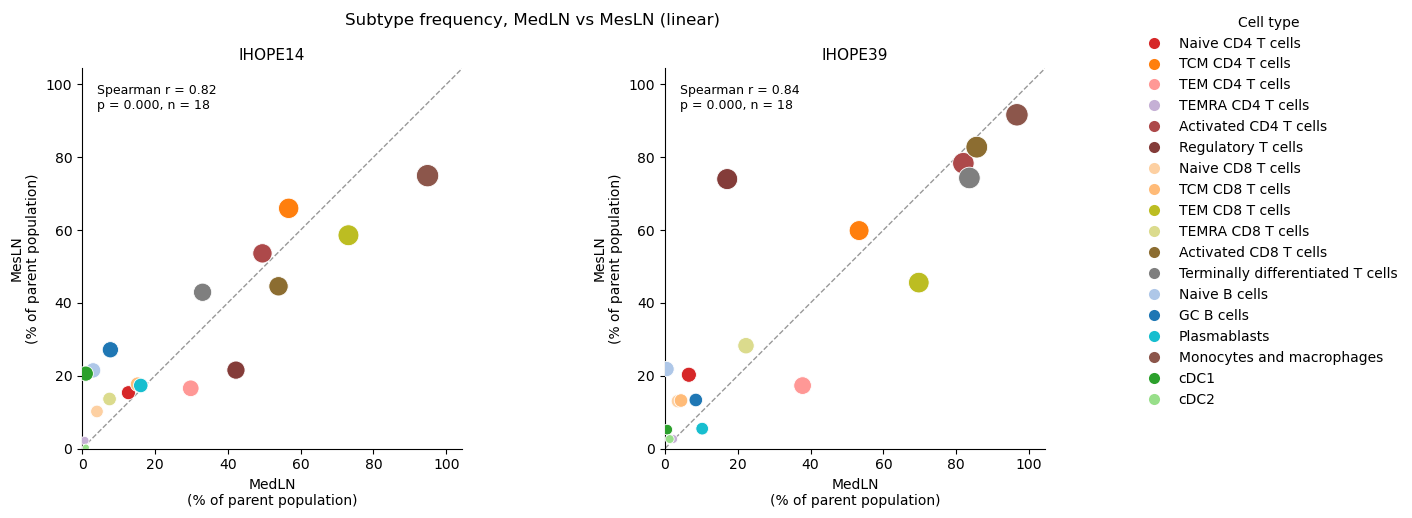

  donor tissue_x tissue_y  n   spearman_r   spearman_p
IHOPE14    MedLN    MesLN 18 0.8183694530 0.0000331031
IHOPE39    MedLN    MesLN 18 0.8369453044 0.0000148599


In [35]:
# Within-donor MedLN vs MesLN correlation, subtype level only

subtype_cell_types = [
    "TN_CD4", "TCM_CD4", "TEM_CD4", "TEMRA_CD4", "Activated_CD4", "Treg", "TfH_like",
    "TN_CD8", "TCM_CD8", "TEM_CD8", "TEMRA_CD8", "Activated_CD8",
    "T_terminal",
    "B_naive", "B_GC", "B_Plasmablast",
    "Monocyte_Macrophage", "cDC1", "cDC2",
]

fig, axes, corr_summary = plot_tissue_correlation_scatter(
    df,
    donors=["IHOPE14", "IHOPE39"],
    tissue_x="MedLN",
    tissue_y="MesLN",
    parent_of=parent_of,
    root_children=immune_types,
    cell_types=subtype_cell_types,
    palette=celltype_colors,
    display_names=celltype_display,
    scale="linear",
    title="Subtype frequency, MedLN vs MesLN (linear)",
)

import pandas as pd
with pd.option_context("display.float_format", lambda v: f"{v:.10f}"):
    print(corr_summary[["donor", "tissue_x", "tissue_y", "n", "spearman_r", "spearman_p"]].to_string(index=False))

In [ ]:
# Quick print check of the numbers

pooled = comparison._pool_donor_tissue(
    df, donors=["IHOPE14", "IHOPE39"], tissue_x="MedLN", tissue_y="MesLN",
)
pooled["donor_tissue"] = pooled["donor"] + "_" + pooled["tissue"]
wide = pooled.pivot_table(
    index="cell_type", columns="donor_tissue", values="pct_total", fill_value=0.0,
)
parent_matrix = normalise_to_parent(wide, parent_of, immune_types)

# raw percentage of total cells, before the parent-relative division
print("pct_total (donor/tissue averaged, % of all cells):")
print(wide.loc[["TN_CD8", "TCM_CD8"]])

print("\npct_parent (% of CD8_T, this is what's plotted):")
print(parent_matrix.loc[["TN_CD8", "TCM_CD8"]])

### Stacked barplots

In [ ]:
LN_ONLY = True  # set True to restrict barplots to lymph node samples only (MedLN + MesLN, drop Spleen)

data_sample = df_ln if LN_ONLY else df
data_tissue = df_tissue_ln if LN_ONLY else df_tissue


Stacked barplot for broad/lineage cell types:

In [ ]:
palette_type = plot_celltype_stacked_barplot(
    data_sample,
    levels=["type"],
    immune_only=IMMUNE_ONLY,
    structural_cell_types=structural_cell_types,
    drop_unclassified=DROP_UNCLASSIFIED,
    tissue_order=tissue_order,
    ylim=(0,100)
)

plot_celltype_stacked_barplot(
    data_sample,
    levels=["type"],
    x="tissue",
    palette=palette_type,
    immune_only=IMMUNE_ONLY,
    structural_cell_types=structural_cell_types,
    drop_unclassified=DROP_UNCLASSIFIED,
    ylim=(0, 100)
)


**Subtype barplots:** Follows `IMMUNE_ONLY` and `LN_ONLY` above. When `IMMUNE_ONLY` is True, percentages are rescaled to 100% of immune cells only.

In [ ]:
palette_immune = plot_celltype_stacked_barplot(
    data_sample,
    levels=["subtype"],
    x="sample",
    immune_only=IMMUNE_ONLY,
    structural_cell_types=structural_cell_types,
    title="Immune cell composition per sample",
    tissue_order=tissue_order,
    ylim=(0, 100)
)

plot_celltype_stacked_barplot(
    data_tissue,
    levels=["subtype"],
    x="tissue",
    palette=palette_immune,
    structural_cell_types=structural_cell_types,
    immune_only=IMMUNE_ONLY,
    ylim=(0, 100)
)


Lineage breakdowns, each rescaled to sum to 100% within that lineage:

In [ ]:
plot_celltype_stacked_barplot(
    data_sample,
    levels=["subtype"],
    x="sample",
    lineage_subset="T",
    lineage_subsets=lineage_subsets,
    title="T cell composition per sample",
    ylabel="Percentage of T cells (CD45+, CD3e+)",
    ylim=(0, 100)
)

plot_celltype_stacked_barplot(
    data_sample,
    levels=["subtype"],
    x="sample",
    lineage_subset="B",
    lineage_subsets=lineage_subsets,
    title="B cell subtype composition per sample",
    ylabel="Percentage of B cells (CD45+, CD20+/CD79a+)",
    ylim=(0, 100)
)

plot_celltype_stacked_barplot(
    data_sample,
    levels=["subtype"],
    x="sample",
    lineage_subset="Myeloid",
    lineage_subsets=lineage_subsets,
    title="DC and monocyte/macrophage subtype composition per sample",
    ylabel="Percentage of myeloid cells (CD45+, CD11+/HLA-DR+)",
    ylim=(0, 100)
)

In [ ]:
plot_celltype_stacked_barplot(
    data_tissue,
    levels=["subtype"],
    x="tissue",
    lineage_subset="T",
    lineage_subsets=lineage_subsets,
    title="T cell composition per tissue",
    ylabel="Percentage of T cells (CD45+, CD3e+)",
    ylim=(0, 100)
)

plot_celltype_stacked_barplot(
    data_tissue,
    levels=["subtype"],
    x="tissue",
    lineage_subset="B",
    lineage_subsets=lineage_subsets,
    title="B cell subtype composition per tissue",
    ylabel="Percentage of B cells (CD45+, CD20+/CD79a+)",
    ylim=(0, 100)
)

plot_celltype_stacked_barplot(
    data_tissue,
    levels=["subtype"],
    x="tissue",
    lineage_subset="Myeloid",
    lineage_subsets=lineage_subsets,
    title="DC and monocyte/macrophage subtype composition per tissue",
    ylabel="Percentage of myeloid cells (CD45+, CD11+/HLA-DR+)",
    ylim=(0, 100)
)

**Updated** T cell subtype barplots: CD8+/CD4+ split

In [ ]:
lineage_subsets["CD4_T"] = ["TN_CD4", "TCM_CD4", "TEM_CD4", "TEMRA_CD4"]
lineage_subsets["CD8_T"] = ["TN_CD8", "TCM_CD8", "TEM_CD8", "TEMRA_CD8"]

In [ ]:
plot_celltype_stacked_barplot(
    df,
    levels=["subtype"],
    x="sample",
    lineage_subset="CD4_T",
    lineage_subsets=lineage_subsets,
    title="CD4 T cell states",
    tissue_order=tissue_order,
    celltype_order=["TEMRA_CD4", "TN_CD4", "TEM_CD4", "TCM_CD4"],
    palette=celltype_colors,
)

In [ ]:
plot_celltype_stacked_barplot(
    df,
    levels=["subtype"],
    x="tissue",
    lineage_subset="CD4_T",
    lineage_subsets=lineage_subsets,
    title="CD4 T cell states",
    tissue_order=tissue_order,
    celltype_order=["TEMRA_CD4", "TN_CD4", "TEM_CD4", "TCM_CD4"],
    palette=celltype_colors,
)

In [ ]:
plot_celltype_stacked_barplot(
    df,
    levels=["subtype"],
    x="sample",
    lineage_subset="CD8_T",
    lineage_subsets=lineage_subsets,
    title="CD8 T cell states",
    tissue_order=tissue_order,
    celltype_order=["TEMRA_CD8", "TN_CD8", "TEM_CD8", "TCM_CD8"],
    palette=celltype_colors,
)

In [ ]:
plot_celltype_stacked_barplot(
    df,
    levels=["subtype"],
    x="tissue",
    lineage_subset="CD8_T",
    lineage_subsets=lineage_subsets,
    title="CD8 T cell states",
    tissue_order=tissue_order,
    celltype_order=["TEMRA_CD8", "TN_CD8", "TEM_CD8", "TCM_CD8"],
    palette=celltype_colors,
)

**Donor-specified strip plots**

In [ ]:
cd4_types = ["Activated_CD4", "Treg"]
cd8_types = ["Activated_CD8"]

df_cd4 = df[df["cell_type"].isin(cd4_types)]
df_cd8 = df[df["cell_type"].isin(cd8_types)]

plot_celltype_stripplot(
    df_cd4,
    level="subtype",
    x="tissue",
    tissue_order=tissue_order,
    donor_colors=donor_colors,
)

plot_celltype_stripplot(
    df_cd8,
    level="subtype",
    x="tissue",
    tissue_order=tissue_order,
    donor_colors=donor_colors,
)

In [ ]:
plot_celltype_stripplot(
    df,
    level="subtype",
    x="tissue",
    tissue_order=tissue_order,
    donor_colors=donor_colors,
    cell_types=["Activated_CD4", "Treg"],
    denominator_cell_type="CD4_T",
)

plot_celltype_stripplot(
    df,
    level="subtype",
    x="tissue",
    tissue_order=tissue_order,
    donor_colors=donor_colors,
    cell_types=["Activated_CD8"],
    denominator_cell_type="CD8_T",
)

In [ ]:
plot_celltype_stripplot(
    df,
    level="subtype",
    x="tissue",
    tissue_order=tissue_order,
    donor_colors=donor_colors,
    #cell_types=["Activated_CD4", "Treg", "Activated_CD8"],    # Uncomment and change if needed
    parent_of=parent_of,
    root_children=immune_types,
    display_names=celltype_display,
)

With Mann-Whitney U test

In [ ]:
plot_celltype_stripplot(
    df,
    level="subtype",
    x="tissue",
    tissue_order=tissue_order,
    donor_colors=donor_colors,
    celltype_order=celltype_order,
    drop_unclassified=DROP_UNCLASSIFIED,
    summary="bar",
    mannwhitney=True,
)

New versions with separate LN/spleens

In [ ]:
df_ln = df[df["tissue"] != "Spleen"]

plot_celltype_stripplot(
    df_ln,
    level="intermediate",
    x="tissue",
    tissue_order=tissue_order,
    donor_colors=donor_colors,
    celltype_order=celltype_order,
    parent_of=parent_of,
    root_children=immune_types,
    display_names=celltype_display,
    summary="bar",
)

plot_celltype_stripplot(
    df_ln,
    level="subtype",
    x="tissue",
    tissue_order=tissue_order,
    donor_colors=donor_colors,
    celltype_order=celltype_order,
    parent_of=parent_of,
    root_children=immune_types,
    display_names=celltype_display,
    summary="bar",
)

In [ ]:
df_spleen = df[df["tissue"] == "Spleen"]

plot_celltype_stripplot(
    df_spleen,
    level="intermediate",
    x="tissue",
    tissue_order=["Spleen"],
    donor_colors=donor_colors,
    celltype_order=celltype_order,
    parent_of=parent_of,
    root_children=immune_types,
    display_names=celltype_display,
    summary="bar",
    reference_df=df_ln,
    reference_group_col="tissue",
)

plot_celltype_stripplot(
    df_spleen,
    level="subtype",
    x="tissue",
    tissue_order=["Spleen"],
    donor_colors=donor_colors,
    celltype_order=celltype_order,
    parent_of=parent_of,
    root_children=immune_types,
    display_names=celltype_display,
    summary="bar",
    reference_df=df_ln,
    reference_group_col="tissue",
)

## Differential screen

Compares fold change (FC) and percentage point difference between mes/med LN.

In [ ]:
import importlib
from scripts import differential_screen as ds
importlib.reload(ds)

In [ ]:
# These paths should direct to your results folder.
# Change if your folder layout is different.
reports_dir = PROJECT_ROOT / "results" / "reports" / NORM
anndata_dir = PROJECT_ROOT / "data" / "processed" / "anndata" / NORM / "celltyped" / "follicledomains"

basenames = [
    "IHOPE14_MedLN_BottomLeft", "IHOPE14_MedLN_TopRight", "IHOPE14_MedLN_BottomRight",
    "IHOPE14_MesLN", "IHOPE20_MedLN", "IHOPE20_Spleen", "IHOPE26_MedLN",
    "IHOPE26_Spleen", "IHOPE27_MedLN", "IHOPE27_Spleen", "IHOPE39_MedLN",
    "IHOPE39_MesLN_A", "IHOPE39_MesLN_B", "IHOPE39_Spleen",
]

# Same parent_of as earlier in the notebook, just imported again here if running independently
from scripts.celltype_config import PARENT_OF as parent_of


Cell type abundance

In [ ]:
long_df = ds.load_celltype_long(reports_dir, basenames)
donor = ds.pool_to_donor_level(long_df)             # pct over all cells (raw, kept)
donor = ds.exclude_unresolved(donor)                # drops _unclassified and _unassigned, adds pct_resolved
donor = ds.add_parent_relative(donor, parent_of)    # pct_parent, invariant to the base

abund = ds.screen(donor, group_a="MesLN", group_b="MedLN", value_col="pct_resolved")
abund_parent = ds.screen(donor, group_a="MesLN", group_b="MedLN", value_col="pct_parent")

Marker positivity

In [ ]:
positivity_csv = "marker_positivity_by_sample.csv"
ds.extract_marker_positivity(anndata_dir, basenames, positivity_csv)  # comment out after first run
marker_donor = ds.marker_to_donor_level(positivity_csv)
markers = ds.screen(marker_donor, group_a="MesLN", group_b="MedLN", value_col="pct")

FC plots with average values

In [ ]:
ds.plot_fc_lollipop(abund, metric="log2fc", points="group", top_n=12,
                    title="MesLN vs MedLN abundance, fold change")
ds.plot_fc_lollipop(abund, metric="diff", points="group", top_n=12,
                    title="MesLN vs MedLN abundance, percentage points")
ds.plot_fc_lollipop(abund_parent, metric="log2fc", points="group", top_n=12,
                    title="MesLN vs MedLN, parent-relative fold change")
ds.plot_fc_lollipop(markers, metric="log2fc", points="group", top_n=15,
                    title="MesLN vs MedLN marker positivity, fold change")

Per-donor FC plots

In [ ]:
import importlib
from scripts import differential_screen as ds
importlib.reload(ds)

abund = ds.screen(donor, group_a="MesLN", group_b="MedLN", value_col="pct_resolved")
abund_parent = ds.screen(donor, group_a="MesLN", group_b="MedLN", value_col="pct_parent")
markers = ds.screen(marker_donor, group_a="MesLN", group_b="MedLN", value_col="pct")

# with dot size scaled by abundance
ds.plot_fc_lollipop(abund, metric="log2fc", points="donor", size_by_abundance=True, top_n=12,
                    title="MesLN vs MedLN abundance, fold change per donor")
ds.plot_fc_lollipop(abund_parent, metric="log2fc", points="donor", size_by_abundance=True, top_n=12,
                    title="MesLN vs MedLN, parent-relative fold change per donor")
ds.plot_fc_lollipop(markers, metric="log2fc", points="donor", size_by_abundance=True, top_n=15,
                    title="MesLN vs MedLN marker positivity per donor")

# same, without abundance sizing (uniform dots)
ds.plot_fc_lollipop(abund, metric="log2fc", points="donor", size_by_abundance=False, top_n=12,
                    title="MesLN vs MedLN abundance, fold change per donor")
                    title="MesLN vs MedLN, parent-relative fold change per donor")
ds.plot_fc_lollipop(markers, metric="log2fc", points="donor", size_by_abundance=False, top_n=15,
                    title="MesLN vs MedLN marker positivity per donor")

**Separate FC plots for CD4/CD8 and manual marker lists**

In [ ]:
# CD4 and CD8 T subsets, matching lineage_subsets in the other notebook
cd4_subsets_naive = ["TN_CD4", "TCM_CD4", "TEM_CD4", "TEMRA_CD4"]
cd8_subsets_naive = ["TN_CD8", "TCM_CD8", "TEM_CD8", "TEMRA_CD8"]
cd4_subsets = ["TCM_CD4", "TEM_CD4", "TEMRA_CD4"]   # naive dropped
cd8_subsets = ["TCM_CD8", "TEM_CD8", "TEMRA_CD8"]

# Union of the DE-top list and the panel list (DE list plus markers only in the panel list)
expanded_markers = [
    # DE-top markers
    "CD11c", "CD1c", "Collagen IV", "HLA-DR", "TCF-1", "CXCL13", "CCR7",
    "CD20", "CD68", "CD107a", "CD141", "CD38", "FOXP3", "IFNG", "Ki67",
    # added from the panel list
    "CCR6", "CD27", "CD45RA", "CD57", "CD69", "ICOS", "Granzyme B", "PD-1", "CD45RO",
]

In [ ]:
plt.style.use("default")

# with naive included
ds.plot_fc_lollipop(
    abund_parent[abund_parent["cell_type"].isin(cd4_subsets_naive)],
    metric="log2fc", points="donor", size_by_abundance=False, top_n=len(cd4_subsets_naive),
    title="MesLN vs MedLN, CD4 T subsets (parent-relative), per donor",
)
ds.plot_fc_lollipop(
    abund_parent[abund_parent["cell_type"].isin(cd8_subsets_naive)],
    metric="log2fc", points="donor", size_by_abundance=False, top_n=len(cd8_subsets_naive),
    title="MesLN vs MedLN, CD8 T subsets (parent-relative), per donor",
)

# without naive
ds.plot_fc_lollipop(
    abund_parent[abund_parent["cell_type"].isin(cd4_subsets)],
    metric="log2fc", points="donor", size_by_abundance=False, top_n=len(cd4_subsets),
    title="MesLN vs MedLN, CD4 memory T subsets (parent-relative), per donor",
)
ds.plot_fc_lollipop(
    abund_parent[abund_parent["cell_type"].isin(cd8_subsets)],
    metric="log2fc", points="donor", size_by_abundance=False, top_n=len(cd8_subsets),
    title="MesLN vs MedLN, CD8 memory T subsets (parent-relative), per donor",
)

In [ ]:
ds.plot_fc_lollipop(
    markers[markers["cell_type"].isin(expanded_markers)],
    metric="log2fc", points="donor", size_by_abundance=False, top_n=len(expanded_markers),
    title="MesLN vs MedLN marker positivity per donor",
)

**Marker positivity in specific populations**

In [ ]:
populations = {
    "CD8_memory": ["subtype_TCM_CD8", "subtype_TEM_CD8", "subtype_TEMRA_CD8"],
    "CD4_memory": ["subtype_TCM_CD4", "subtype_TEM_CD4", "subtype_TEMRA_CD4"],
}

pop_tables = ds.extract_marker_positivity_in_populations(anndata_dir, basenames, populations)

markers_cd8_mem = ds.screen(pop_tables["CD8_memory"], group_a="MesLN", group_b="MedLN", value_col="pct")
markers_cd4_mem = ds.screen(pop_tables["CD4_memory"], group_a="MesLN", group_b="MedLN", value_col="pct")

In [ ]:
with plt.style.context("default"):
    ds.plot_fc_lollipop(
        markers_cd8_mem[markers_cd8_mem["cell_type"].isin(expanded_markers)],
        metric="log2fc", points="donor", size_by_abundance=False, top_n=len(expanded_markers),
        title="MesLN vs MedLN marker positivity within CD8 memory T, per donor",
    )
    ds.plot_fc_lollipop(
        markers_cd4_mem[markers_cd4_mem["cell_type"].isin(expanded_markers)],
        metric="log2fc", points="donor", size_by_abundance=False, top_n=len(expanded_markers),
        title="MesLN vs MedLN marker positivity within CD4 memory T, per donor",
    )

Summary tables

In [ ]:
pd.set_option("display.max_rows", None, "display.width", None)

print("ABUNDANCE (percentage of resolved cells, per level)")
print(abund.to_string(index=False))

print("\nABUNDANCE parent-relative")
print(abund_parent.to_string(index=False))

print("\nMARKER positivity")
print(markers.to_string(index=False))